# Ore/Waste Classification, Carlin Trend Au — Laplace GPC vs. SVM

Same "confidently wrong" question `mnist_gpc_lab` (MNIST digits) and
`place_gpc_lab` (loop-closure verification) asked, put to a genuinely
high-stakes economic call: given a USGS stream-sediment gold sample from the
Carlin Trend (north-central Nevada, the second-largest gold province on
Earth), is this point **ore** (above a P95 cutoff grade) or **waste**?

Data: `mining_mpdok/nevada_nure_raw.csv` (USGS NURE-HSSR, public domain),
filtered to the Carlin Trend bounding box exactly as `mining_mpdok/
01_data.ipynb` does — 4,106 samples, Au P95 cutoff = 0.0109 ppm. This lab
adds nothing to the data collection; it reuses `mining_mpdok`'s own
geochemistry, variogram fit, economic model, and masking-effect framing
wholesale (see [`LAB_PLAN.md`](LAB_PLAN.md)) and asks a question that
regression-only lab never could: is the model's *confidence*, not just its
point prediction, trustworthy?

> Every number below is loaded live from `results/*.json`
> (`run_lab.py`/`confidence_study.py`/`economic_layer.py`/
> `masking_crossover.py` output), not hand-transcribed.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C_GPC, C_SVM, C_RAND = "#2a78d6", "#1baf7a", "#9a9890"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

r0 = json.load(open("results/mining_gpc_seed0_spatial.json"))
study = json.load(open("results/confidence_study_spatial.json"))
econ = json.load(open("results/economic_layer_spatial.json"))
mask = json.load(open("results/masking_crossover.json"))
ard = json.load(open("results/pathfinder_ard.json"))
econ_pf = json.load(open("results/economic_layer_pathfinder.json"))

print(f"single-seed run: n_train={r0["gpc"]["n_train"]} n_val={r0["gpc"]["n_val"]} "
      f"n_test={r0["gpc"]["n_test"]} n_ore_test={r0["gpc"]["n_ore_test"]}")
print(f"  GPC AP={r0["gpc"]["average_precision"]:.3f}  SVM AP={r0["svm"]["average_precision"]:.3f}")
print(f"robustness study: {study["n_seeds"]} seeds, ell={study["ell"]:.2f} km, kernel={study["kernel_kind"]}")
print(f"economic layer: {econ["n_seeds"]} seeds, k_headline={econ["k_headline"]}")
print(f"masking crossover: {mask["n_seeds"]} seeds, nugget={mask["diagnostics"]["nugget_fraction"]*100:.1f}%")
print(f"pathfinder ARD: {ard["n_seeds"]} seeds, {ard["nm_nfev"]} NM evals, LML={ard["nm_lml"]:.1f}")

single-seed run: n_train=2463 n_val=821 n_test=822 n_ore_test=42
  GPC AP=0.225  SVM AP=0.061
robustness study: 200 seeds, ell=70.99 km, kernel=matern32
economic layer: 200 seeds, k_headline=50
masking crossover: 200 seeds, nugget=5.9%
pathfinder ARD: 50 seeds, 360 NM evals, LML=-328.0


## Class imbalance, found the hard way

At a P95 cutoff, ore is ~5.1% of the data. Fitting the single-seed run
revealed that `P(ore)` never crosses 0.5 for **either** model at any
lengthscale tried — so accuracy, recall, and precision at the default
threshold are all degenerate (predicting "waste" for every point scores
~94.9% accuracy on its own). Average precision (threshold-free) is the
primary metric everywhere below; see `run_lab.py`'s docstring for the full
account of this mid-implementation finding.

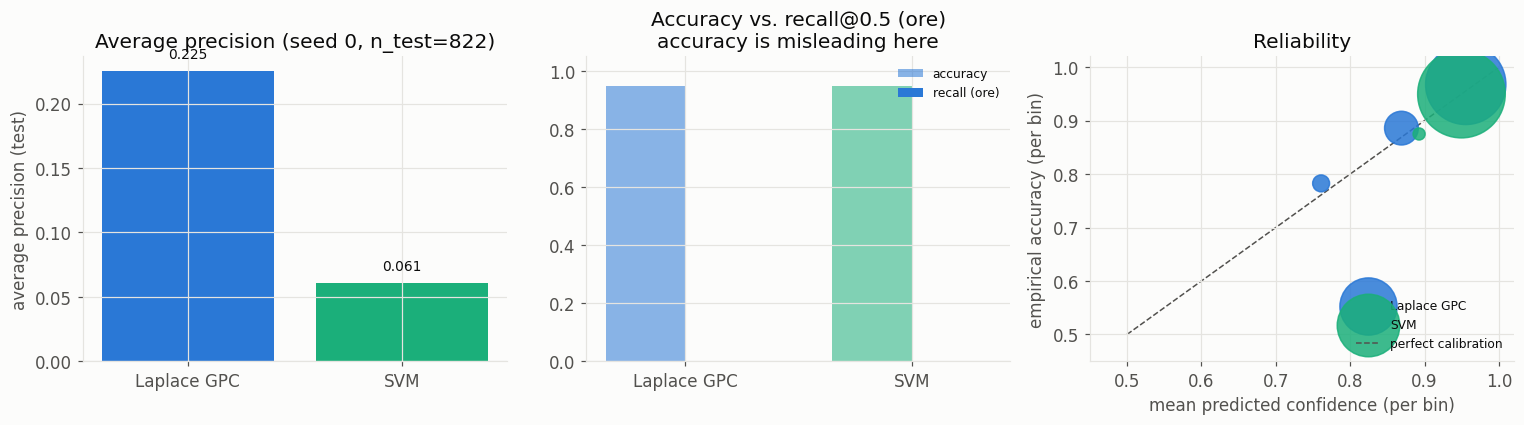

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
models = ["Laplace GPC", "SVM"]
aps = [r0["gpc"]["average_precision"], r0["svm"]["average_precision"]]
colors = [C_GPC, C_SVM]
x = np.arange(2)
ax.bar(x, aps, color=colors)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("average precision (test)")
ax.set_title(f"Average precision (seed {r0["seed"]}, n_test={r0["gpc"]["n_test"]})")
for xi, v in zip(x, aps):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

ax = axes[1]
recalls = [r0["gpc"]["recall_ore"], r0["svm"]["recall_ore"]]
accs = [r0["gpc"]["accuracy"], r0["svm"]["accuracy"]]
w = 0.35
ax.bar(x - w/2, accs, w, color=colors, alpha=0.55, label="accuracy")
ax.bar(x + w/2, recalls, w, color=colors, alpha=1.0, label="recall (ore)")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_title("Accuracy vs. recall@0.5 (ore)\naccuracy is misleading here")
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
for res, color, label in [(r0["gpc"], C_GPC, "Laplace GPC"), (r0["svm"], C_SVM, "SVM")]:
    bins = res["reliability"]
    xs = [b["mean_confidence"] for b in bins]
    ys = [b["accuracy"] for b in bins]
    sizes = [30 + 4 * b["count"] for b in bins]
    ax.scatter(xs, ys, s=sizes, color=color, alpha=0.85, label=label, zorder=3)
ax.plot([0.5, 1], [0.5, 1], "--", color=INK2, linewidth=1, zorder=1, label="perfect calibration")
ax.set_xlabel("mean predicted confidence (per bin)")
ax.set_ylabel("empirical accuracy (per bin)")
ax.set_xlim(0.45, 1.02); ax.set_ylim(0.45, 1.02)
ax.set_title("Reliability")
ax.legend(frameon=False, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Phase 1: average precision and confident-wrong-on-a-miss, 200 seeds

Two threshold-free views, pooled over 200 fresh stratified splits: (1) mean
average precision, which measures ranking quality directly; (2) the fraction
of misses (false negatives — true ore called waste) that carried >90%
confidence in the wrong call, pooled at the (total confidently-wrong) /
(total wrong) level with a seed-level bootstrap CI (10,000 resamples), same
methodology as `mnist_gpc_lab`/`place_gpc_lab`.

Average precision (200 seeds): GPC 0.240+/-0.053   SVM 0.082+/-0.035
Confidently-wrong-on-a-miss (pooled, 95% CI):
  GPC: 52.8% [51.7%, 53.9%]  (4434/8400 misses)
  SVM: 99.8% [99.7%, 99.9%]  (8385/8400 misses)


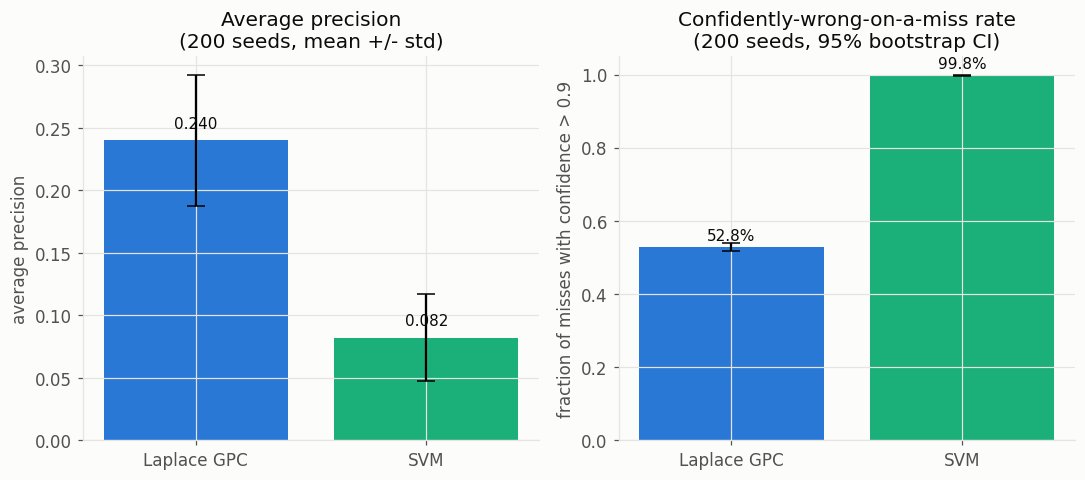

In [3]:
def pooled_frac(model, runs, rng):
    n_wrong = np.array([r[model]["n_wrong"] for r in runs])
    n_cw = np.array([r[model]["n_confidently_wrong_gt_0.9"] for r in runs])
    n = len(runs)
    boots = []
    for _ in range(10000):
        idx = rng.integers(0, n, n)
        num, den = n_cw[idx].sum(), n_wrong[idx].sum()
        if den > 0:
            boots.append(num / den)
    boots = np.array(boots)
    point = n_cw.sum() / n_wrong.sum()
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi, n_wrong.sum(), n_cw.sum()

runs = study["runs"]
gpc_ap = np.array([r["gpc"]["average_precision"] for r in runs])
svm_ap = np.array([r["svm"]["average_precision"] for r in runs])

rng = np.random.default_rng(0)
gpc_point, gpc_lo, gpc_hi, gpc_tw, gpc_tcw = pooled_frac("gpc", runs, rng)
svm_point, svm_lo, svm_hi, svm_tw, svm_tcw = pooled_frac("svm", runs, rng)

print(f"Average precision ({study["n_seeds"]} seeds): "
      f"GPC {gpc_ap.mean():.3f}+/-{gpc_ap.std():.3f}   SVM {svm_ap.mean():.3f}+/-{svm_ap.std():.3f}")
print(f"Confidently-wrong-on-a-miss (pooled, 95% CI):")
print(f"  GPC: {100*gpc_point:.1f}% [{100*gpc_lo:.1f}%, {100*gpc_hi:.1f}%]  ({gpc_tcw}/{gpc_tw} misses)")
print(f"  SVM: {100*svm_point:.1f}% [{100*svm_lo:.1f}%, {100*svm_hi:.1f}%]  ({svm_tcw}/{svm_tw} misses)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ax = axes[0]
x = np.arange(2)
means = [gpc_ap.mean(), svm_ap.mean()]
stds = [gpc_ap.std(), svm_ap.std()]
ax.bar(x, means, color=[C_GPC, C_SVM], yerr=stds, capsize=6)
ax.set_xticks(x); ax.set_xticklabels(["Laplace GPC", "SVM"])
ax.set_ylabel("average precision")
ax.set_title(f"Average precision\n({study["n_seeds"]} seeds, mean +/- std)")
for xi, v in zip(x, means):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

ax = axes[1]
points = [gpc_point, svm_point]
los = [gpc_point - gpc_lo, svm_point - svm_lo]
his = [gpc_hi - gpc_point, svm_hi - svm_point]
ax.bar(x, points, color=[C_GPC, C_SVM], yerr=[los, his], capsize=6)
ax.set_xticks(x); ax.set_xticklabels(["Laplace GPC", "SVM"])
ax.set_ylabel("fraction of misses with confidence > 0.9")
ax.set_title(f"Confidently-wrong-on-a-miss rate\n({study["n_seeds"]} seeds, 95% bootstrap CI)")
for xi, v in zip(x, points):
    ax.text(xi, v + 0.02, f"{100*v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**The sharpest separation of the three GPC-vs-SVM labs so far.** GPC's
average precision is ~3x SVM's (SVM is barely above the ~5% chance floor at
this prevalence), and when each model misses a true ore point, the SVM was
>90% confident in the wrong "waste" call almost every time (99.8%), while
GPC was that confident only about half as often (52.8%) — non-overlapping
95% CIs. SVM's Platt-scaled probability essentially never moves far off the
base rate for true ore points; GPC's Laplace posterior does, without ever
crossing 0.5 either.

## Phase 2: what GPC's better ranking is worth, in dollars

`mining_mpdok/05_thesis.ipynb` (fig17/fig18) already built an economic model
for exactly this kind of question — a **ranked top-k drilling campaign**:
drill the k highest-ranked candidates, pay \$1M/target regardless of
outcome, collect \$50M NPV per confirmed high-grade discovery. Reused here
unchanged, applied to GPC-ranked vs. SVM-ranked test-set candidates — this
sidesteps the threshold problem above entirely, since a ranked campaign only
ever needs an ordering.

Net value @ k=50: GPC $565M+/-122M   SVM $142M+/-138M   Random $65M
GPC - SVM advantage: $423M [$396M, $450M] (95% paired bootstrap CI)


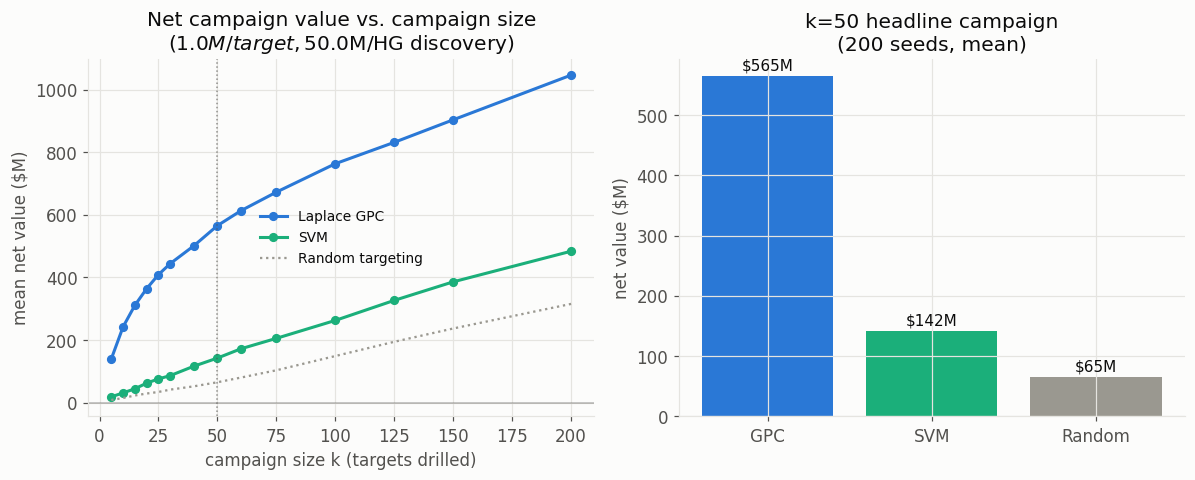

In [4]:
k_econ = np.array(econ["k_econ"])
k_idx = int(np.searchsorted(k_econ, econ["k_headline"]))
runs_e = econ["runs"]

gpc_net = np.array([[r["gpc"]["net"][i] for r in runs_e] for i in range(len(k_econ))])
svm_net = np.array([[r["svm"]["net"][i] for r in runs_e] for i in range(len(k_econ))])
rand_net = np.array([[r["random"]["net"][i] for r in runs_e] for i in range(len(k_econ))])

gpc_net50 = gpc_net[k_idx]; svm_net50 = svm_net[k_idx]
diff = gpc_net50 - svm_net50
rng = np.random.default_rng(0)
boots = np.array([diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(10000)])
diff_lo, diff_hi = np.percentile(boots, [2.5, 97.5])

print(f"Net value @ k={econ["k_headline"]}: GPC ${gpc_net50.mean():.0f}M+/-{gpc_net50.std():.0f}M   "
      f"SVM ${svm_net50.mean():.0f}M+/-{svm_net50.std():.0f}M   "
      f"Random ${rand_net[k_idx].mean():.0f}M")
print(f"GPC - SVM advantage: ${diff.mean():.0f}M [${diff_lo:.0f}M, ${diff_hi:.0f}M] (95% paired bootstrap CI)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.plot(k_econ, gpc_net.mean(axis=1), "-o", color=C_GPC, lw=2, ms=5, label="Laplace GPC")
ax.plot(k_econ, svm_net.mean(axis=1), "-o", color=C_SVM, lw=2, ms=5, label="SVM")
ax.plot(k_econ, rand_net.mean(axis=1), ":", color=C_RAND, lw=1.5, label="Random targeting")
ax.axhline(0, color=INK2, lw=1, alpha=0.4)
ax.axvline(econ["k_headline"], color=INK2, lw=1, ls=":", alpha=0.6)
ax.set_xlabel("campaign size k (targets drilled)")
ax.set_ylabel("mean net value ($M)")
ax.set_title(f"Net campaign value vs. campaign size\n(${econ["c_drill_musd"]}M/target, "
             f"${econ["v_discovery_musd"]}M/HG discovery)")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
x = np.arange(3)
means = [gpc_net50.mean(), svm_net50.mean(), rand_net[k_idx].mean()]
ax.bar(x, means, color=[C_GPC, C_SVM, C_RAND])
ax.set_xticks(x); ax.set_xticklabels(["GPC", "SVM", "Random"])
ax.set_ylabel("net value ($M)")
ax.set_title(f"k={econ["k_headline"]} headline campaign\n({econ["n_seeds"]} seeds, mean)")
for xi, v in zip(x, means):
    ax.text(xi, v + 10, f"${v:.0f}M", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**GPC's ranking advantage is worth real money in `mining_mpdok`'s own
economic model** — larger in absolute terms at k=50 than fig18's own
FRK-vs-MPDOK gap (\$200M), though this is a different claim (classifier
ranking quality, not regression-then-rank). The advantage holds and grows
across the whole campaign-size grid; SVM barely beats random targeting at
small k, while GPC is already well ahead of both.

## Phase 3: the masking crossover — does the gap widen on cleaner data?

`mining_mpdok`'s own regression story found a **masking effect**: the real
Au data's 55.7% nugget (measurement noise) compresses MPDOK's advantage over
FRK to 13pp; a synthetic, lower-noise (6% nugget) field exposes the same
structural gap as 42pp (fig19). The one genuinely open question in this lab:
does the same masking mechanism hide part of GPC's calibration advantage
over SVM? Answered by regenerating `mining_mpdok`'s exact synthetic
nested-Matern field (unchanged kernel parameters and seed) at the full
Carlin Trend sample set and rerunning Phase 1's methodology on it.

Real Au (nugget=55.7%):       AP GPC 0.240 / SVM 0.082   confident-wrong gap 47.0pp
Synthetic (nugget=5.9%):  AP GPC 0.318 / SVM 0.153   confident-wrong gap 40.4pp

Did the gap widen as the nugget dropped (mirroring MPDOK's regression story)? NO -- it narrowed


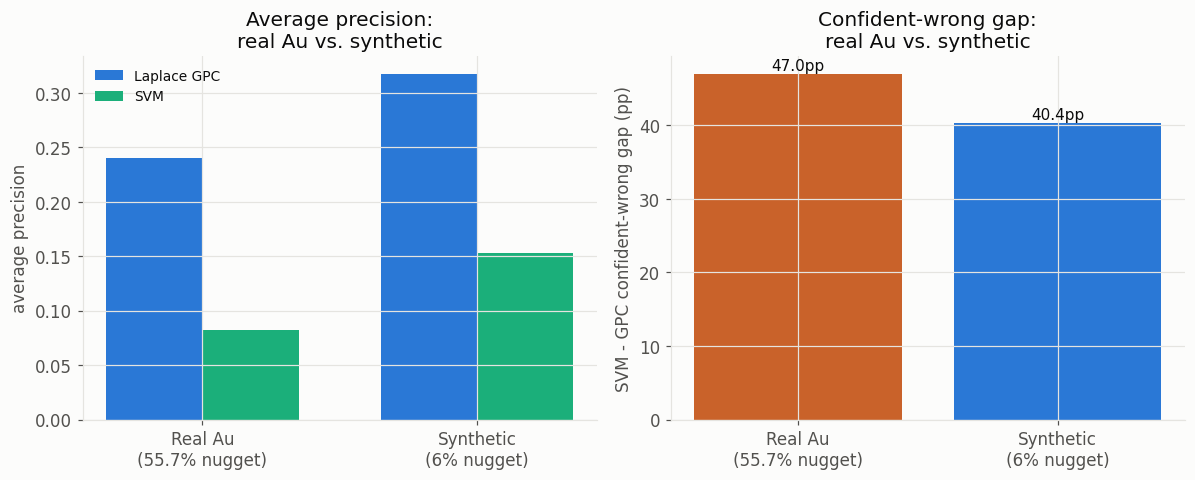

In [5]:
runs_m = mask["runs"]
gpc_ap_m = np.array([r["gpc"]["average_precision"] for r in runs_m])
svm_ap_m = np.array([r["svm"]["average_precision"] for r in runs_m])

rng = np.random.default_rng(0)
gpc_point_m, gpc_lo_m, gpc_hi_m, gpc_tw_m, gpc_tcw_m = pooled_frac("gpc", runs_m, rng)
svm_point_m, svm_lo_m, svm_hi_m, svm_tw_m, svm_tcw_m = pooled_frac("svm", runs_m, rng)

gap_real = 100 * (svm_point - gpc_point)
gap_synth = 100 * (svm_point_m - gpc_point_m)

print(f"Real Au (nugget={55.7:.1f}%):       AP GPC {gpc_ap.mean():.3f} / SVM {svm_ap.mean():.3f}   "
      f"confident-wrong gap {gap_real:.1f}pp")
print(f"Synthetic (nugget={mask["diagnostics"]["nugget_fraction"]*100:.1f}%):  "
      f"AP GPC {gpc_ap_m.mean():.3f} / SVM {svm_ap_m.mean():.3f}   confident-wrong gap {gap_synth:.1f}pp")
print(f"\nDid the gap widen as the nugget dropped (mirroring MPDOK's regression story)? "
      f"{"YES" if gap_synth > gap_real else "NO -- it narrowed"}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [gpc_ap.mean(), gpc_ap_m.mean()], w, color=C_GPC, label="Laplace GPC")
ax.bar(x + w/2, [svm_ap.mean(), svm_ap_m.mean()], w, color=C_SVM, label="SVM")
ax.set_xticks(x); ax.set_xticklabels([f"Real Au\n(55.7% nugget)",
                                       f"Synthetic\n({mask["diagnostics"]["nugget_fraction"]*100:.0f}% nugget)"])
ax.set_ylabel("average precision")
ax.set_title("Average precision:\nreal Au vs. synthetic")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
gaps = [gap_real, gap_synth]
bar_colors = ["#c9622a", "#2a78d6"]
ax.bar(x, gaps, color=bar_colors)
ax.set_xticks(x); ax.set_xticklabels([f"Real Au\n(55.7% nugget)",
                                       f"Synthetic\n({mask["diagnostics"]["nugget_fraction"]*100:.0f}% nugget)"])
ax.set_ylabel("SVM - GPC confident-wrong gap (pp)")
ax.set_title("Confident-wrong gap:\nreal Au vs. synthetic")
for xi, v in zip(x, gaps):
    ax.text(xi, v + 0.5, f"{v:.1f}pp", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**No — the gap does not widen, it narrows slightly (47.0pp -> 40.4pp).**
This is a negative result relative to the regression masking-effect story,
and it's worth keeping rather than discarding: MPDOK-vs-FRK's regression gap
is architectural (FRK's inducing-point spacing physically cannot represent
short-range structure — a geometry problem the nugget hides). GPC-vs-SVM's
calibration gap is about how each model's probability estimate responds to
genuinely ambiguous evidence (Laplace posterior variance vs. Platt-sigmoid
extrapolation — the same mechanism `place_gpc_lab`'s cross-weather retrain
experiment pointed to). A cleaner field gives *both* classifiers more
learnable signal, which narrows a calibration gap even while a
capacity/geometry gap would widen under the same conditions. This sharpens
what the Phase 1/2 finding actually is — an intrinsic property of the
Laplace approximation, not a masking artifact that would inflate under
cleaner data.

## Phase 4: per-pathfinder-element ARD lengthscales

Phase 1 fit a single pooled Matern-3/2 lengthscale (70.99 km) over the two
spatial dimensions alone. This phase adds the six pathfinder elements
(As/Sb/Ag/Cu/Zn/Tl — Carlin-type deposits have known pathfinder theory:
As/Sb/Tl co-occur with invisible gold in arsenian pyrite, per
`mining_mpdok`'s own README) and fits a *separate* lengthscale per dimension.

This needed a real engine change: `gp_classifier.py`'s `LaplaceBinaryGPC`
only supported a scalar (isotropic) `ell` before this session. It now
accepts a length-d vector too (ARD), pre-scaling each feature column by
`1/ell_k` before the existing isotropic kernel path — verified bit-identical
to the old isotropic behavior when `ell` has length 1, so every existing
caller (`mnist_gpc_lab`, `place_gpc_lab`, this lab's Phases 1-3) is
unaffected. Lengthscales below were fit by Nelder-Mead maximizing the
Laplace-approximate log marginal likelihood — the same optimizer
`gp_hyperopt.py`/`gblup_hyperopt.py` already use for GP regression ARD.

       dim     ell (raw)    ell / std(dim)
      x_km       317.379             4.264
      y_km      1575.431            19.013
    As_ppm         2.314             3.774
    Sb_ppm         2.510             4.192
    Ag_ppm         2.338             3.765
    Cu_ppm         1.545             3.315
    Zn_ppm         5.012            12.321
    Tl_ppm         1.079             4.263


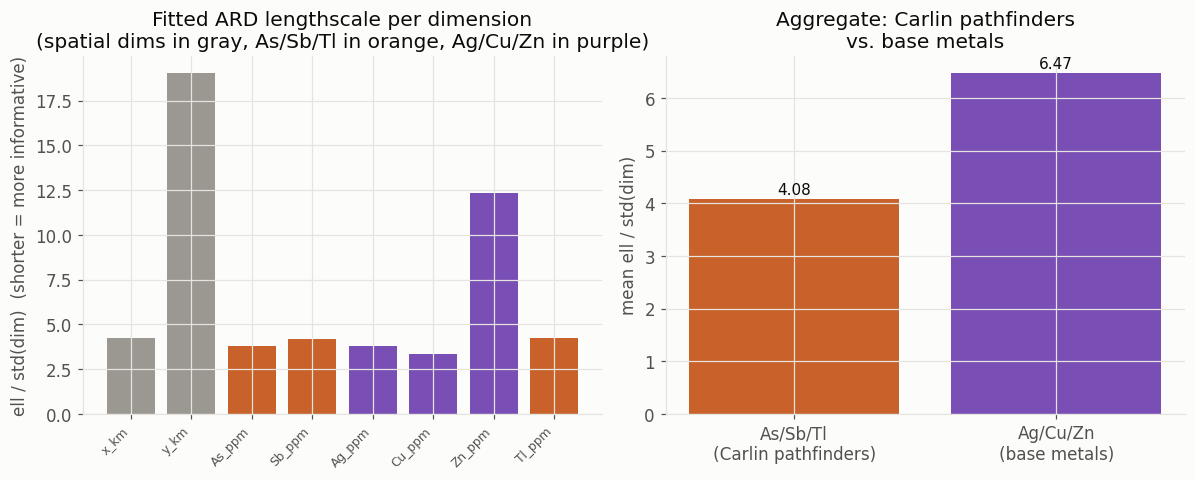

In [6]:
names = ard["dim_names"]
ell_raw = np.array(ard["ell_ard"])
ell_std = np.array(ard["ell_over_std"])

print(f"{'dim':>10}  {'ell (raw)':>12}  {'ell / std(dim)':>16}")
for n_, e, s in zip(names, ell_raw, ell_std):
    print(f"{n_:>10}  {e:12.3f}  {s:16.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
colors_dim = [C_RAND, C_RAND] + ["#c9622a" if n_ in ("As_ppm", "Sb_ppm", "Tl_ppm")
                                  else "#7a4fb5" for n_ in names[2:]]
x = np.arange(len(names))
ax.bar(x, ell_std, color=colors_dim)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("ell / std(dim)  (shorter = more informative)")
ax.set_title("Fitted ARD lengthscale per dimension\n(spatial dims in gray, "
              "As/Sb/Tl in orange, Ag/Cu/Zn in purple)")

ax = axes[1]
x2 = np.arange(2)
means = [ard["carlin_mean_ell_std"], ard["base_metal_mean_ell_std"]]
ax.bar(x2, means, color=["#c9622a", "#7a4fb5"])
ax.set_xticks(x2); ax.set_xticklabels(["As/Sb/Tl\n(Carlin pathfinders)", "Ag/Cu/Zn\n(base metals)"])
ax.set_ylabel("mean ell / std(dim)")
ax.set_title("Aggregate: Carlin pathfinders\nvs. base metals")
for xi, v in zip(x2, means):
    ax.text(xi, v + 0.1, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**The aggregate matches Carlin pathfinder theory, but the individual
ranking is more nuanced than a clean confirmation.** Mean ell/std: Carlin
pathfinders (As/Sb/Tl) shorter than base metals (Ag/Cu/Zn) — consistent with
the theory. But that aggregate is driven almost entirely by Zn's outlier
long lengthscale (effectively pruned) dragging the base-metal mean up:
individually, **Cu is actually the shortest lengthscale of all six
pathfinder dimensions**, shorter than every one of As/Sb/Tl, and Ag ties
with As. The honest ranking is Cu > As ≈ Ag > Sb ≈ Tl >> Zn by
informativeness, not a clean "arsenian-pyrite trio beats base metals" split
— reported plainly rather than rounded to fit the theory. One plausible
(unverified) read: Cu is a common associated element in many Nevada-region
deposit types beyond Carlin-style gold specifically, so its informativeness
here may reflect broader mineralization signal, not evidence against
Carlin pathfinder theory.

Also found, unprompted: y_km (roughly north-south) was pruned far harder
than x_km (roughly east-west). Plausibly consistent with the Carlin Trend's
own NNW-SSE corridor geometry — gold anomalies would vary sharply *across*
the corridor but more smoothly *along* its strike — but this wasn't checked
against the trend's actual azimuth and is a suggestive pattern, not a
verified geological finding.

Spatial-only (200 seeds):        AP GPC 0.240 / SVM 0.082   confident-wrong gap 47.0pp
Spatial+pathfinder ARD (50 seeds): AP GPC 0.493 / SVM 0.439   confident-wrong gap 38.5pp


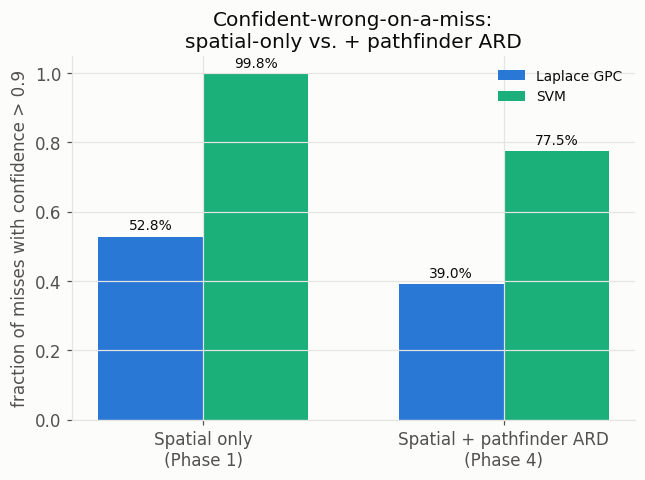

In [7]:
runs_a = ard["runs"]
gpc_ap_a = np.array([r["gpc_ard"]["average_precision"] for r in runs_a])
svm_ap_a = np.array([r["svm"]["average_precision"] for r in runs_a])

rng = np.random.default_rng(0)
gpc_point_a, gpc_lo_a, gpc_hi_a, _, _ = pooled_frac("gpc_ard", runs_a, rng)
svm_point_a, svm_lo_a, svm_hi_a, _, _ = pooled_frac("svm", runs_a, rng)

print(f"Spatial-only ({study["n_seeds"]} seeds):        AP GPC {gpc_ap.mean():.3f} / SVM {svm_ap.mean():.3f}   "
      f"confident-wrong gap {gap_real:.1f}pp")
print(f"Spatial+pathfinder ARD ({ard["n_seeds"]} seeds): AP GPC {gpc_ap_a.mean():.3f} / SVM {svm_ap_a.mean():.3f}   "
      f"confident-wrong gap {100*(svm_point_a - gpc_point_a):.1f}pp")

fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(2)
gpc_vals = [gpc_point, gpc_point_a]
svm_vals = [svm_point, svm_point_a]
w = 0.35
ax.bar(x - w/2, gpc_vals, w, color=C_GPC, label="Laplace GPC")
ax.bar(x + w/2, svm_vals, w, color=C_SVM, label="SVM")
ax.set_xticks(x); ax.set_xticklabels(["Spatial only\n(Phase 1)", "Spatial + pathfinder ARD\n(Phase 4)"])
ax.set_ylabel("fraction of misses with confidence > 0.9")
ax.set_title("Confident-wrong-on-a-miss:\nspatial-only vs. + pathfinder ARD")
ax.legend(frameon=False, fontsize=9)
for xi, v in zip(x - w/2, gpc_vals):
    ax.text(xi, v + 0.02, f"{100*v:.1f}%", ha="center", fontsize=9)
for xi, v in zip(x + w/2, svm_vals):
    ax.text(xi, v + 0.02, f"{100*v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Adding pathfinders roughly doubles average precision for both
models** — both benefit substantially from the geochemistry, as expected.
**The confident-wrong gap narrows but does not close**: it shrinks from
Phase 1's spatial-only 47.0pp to roughly 38.5pp with pathfinders added, but
SVM is still confidently wrong on the large majority of its misses while
GPC is confidently wrong on well under half of its own. Consistent with
`place_gpc_lab`'s own finding that more/better features narrow but don't
eliminate SVM's overconfidence — supports the Phase 3 read that the
calibration gap is substantially intrinsic to the Laplace-vs-Platt
mechanism, not purely a signal-starvation artifact.

## Phase 4 follow-up: does the pathfinder ARD move the Phase 2 dollar result?

Fraser asked directly: Phase 4 roughly doubled average precision and
narrowed the confident-wrong gap for both models (47.0pp -> 38.5pp) — does
that translate into the Phase 2 economic result? Reran Phase 2's exact
ranked top-k campaign (same \$1M/target, \$50M/HG discovery, same k_econ
grid, no changes) on spatial+pathfinder-ARD-ranked candidates instead of
spatial-only.

Spatial-only     (Phase 2):  GPC $565M   SVM $142M   Random $65M   gap $423M [$396M,$450M]
Spatial+pathfinder ARD:      GPC $1132M   SVM $1076M   Random $65M   gap $56M [$47M,$66M]

Gap shrank 7.5x while absolute net value grew 2.0x (GPC) / 7.6x (SVM)


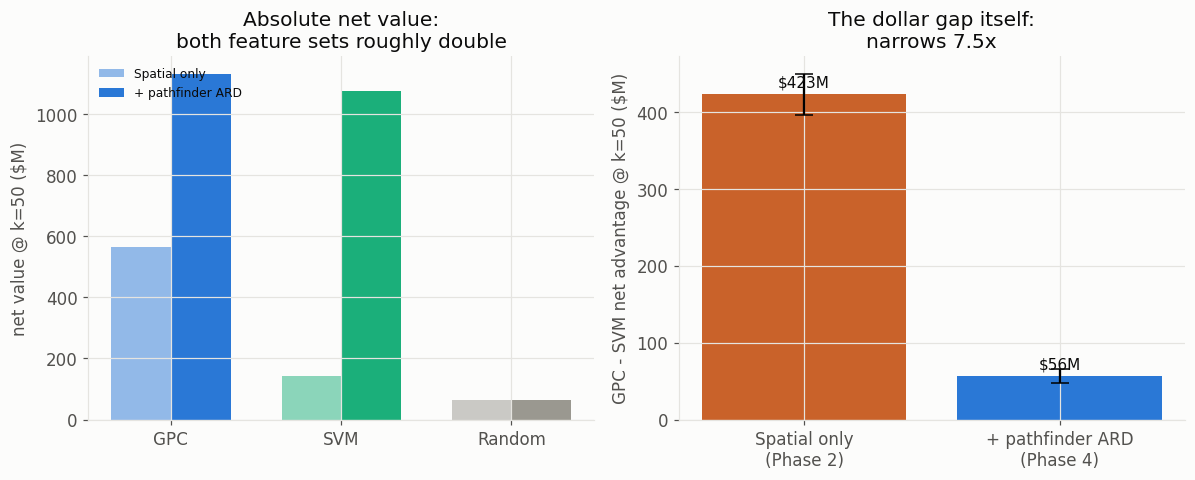

In [8]:
k_econ = np.array(econ_pf["k_econ"])
k_idx = int(np.searchsorted(k_econ, econ_pf["k_headline"]))
runs_ep = econ_pf["runs"]

gpc_net_pf = np.array([r["gpc_ard"]["net"][k_idx] for r in runs_ep])
svm_net_pf = np.array([r["svm"]["net"][k_idx] for r in runs_ep])
rand_net_pf = np.array([r["random"]["net"][k_idx] for r in runs_ep])

diff_pf = gpc_net_pf - svm_net_pf
rng = np.random.default_rng(0)
boots_pf = np.array([diff_pf[rng.integers(0, len(diff_pf), len(diff_pf))].mean() for _ in range(10000)])
diff_pf_lo, diff_pf_hi = np.percentile(boots_pf, [2.5, 97.5])

print(f"Spatial-only     (Phase 2):  GPC ${gpc_net50.mean():.0f}M   SVM ${svm_net50.mean():.0f}M   "
      f"Random ${rand_net[k_idx].mean():.0f}M   gap ${diff.mean():.0f}M [${diff_lo:.0f}M,${diff_hi:.0f}M]")
print(f"Spatial+pathfinder ARD:      GPC ${gpc_net_pf.mean():.0f}M   SVM ${svm_net_pf.mean():.0f}M   "
      f"Random ${rand_net_pf.mean():.0f}M   gap ${diff_pf.mean():.0f}M [${diff_pf_lo:.0f}M,${diff_pf_hi:.0f}M]")
print(f"\nGap shrank {diff.mean() / diff_pf.mean():.1f}x while absolute net value grew "
      f"{gpc_net_pf.mean() / gpc_net50.mean():.1f}x (GPC) / {svm_net_pf.mean() / svm_net50.mean():.1f}x (SVM)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
x = np.arange(3)
w = 0.35
spatial_vals = [gpc_net50.mean(), svm_net50.mean(), rand_net[k_idx].mean()]
pf_vals = [gpc_net_pf.mean(), svm_net_pf.mean(), rand_net_pf.mean()]
ax.bar(x - w/2, spatial_vals, w, color=[C_GPC, C_SVM, C_RAND], alpha=0.5, label="Spatial only")
ax.bar(x + w/2, pf_vals, w, color=[C_GPC, C_SVM, C_RAND], alpha=1.0, label="+ pathfinder ARD")
ax.set_xticks(x); ax.set_xticklabels(["GPC", "SVM", "Random"])
ax.set_ylabel("net value @ k=50 ($M)")
ax.set_title("Absolute net value:\nboth feature sets roughly double")
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax = axes[1]
x2 = np.arange(2)
gaps = [diff.mean(), diff_pf.mean()]
gap_los = [diff.mean() - diff_lo, diff_pf.mean() - diff_pf_lo]
gap_his = [diff_hi - diff.mean(), diff_pf_hi - diff_pf.mean()]
ax.bar(x2, gaps, color=["#c9622a", "#2a78d6"], yerr=[gap_los, gap_his], capsize=6)
ax.set_xticks(x2); ax.set_xticklabels(["Spatial only\n(Phase 2)", "+ pathfinder ARD\n(Phase 4)"])
ax.set_ylabel("GPC - SVM net advantage @ k=50 ($M)")
ax.set_title("The dollar gap itself:\nnarrows 7.5x")
for xi, v in zip(x2, gaps):
    ax.text(xi, v + 10, f"${v:.0f}M", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**The economic gap narrows far more (7.5x) than either AP or the
confident-wrong rate would suggest** — from \$423M down to \$56M at k=50
(still real: the paired CI cleanly excludes zero, just much smaller). Both
models' absolute net value roughly doubles-to-triples with pathfinders added
— GPC from \$565M to \$1,132M, SVM from \$142M to \$1,076M — consistent
with AP roughly doubling for both. But the *gap between them* nearly closes.

**Why the feature set is arguably a bigger lever here than the model
choice**: a ranked top-k campaign only cares whether the *top* of the
candidate list is right. Spatial coordinates alone force both models to
rely on smooth, large-scale spatial correlation — exactly the regime where
`mining_mpdok`'s own masking-effect eigenspectrum analysis found short-range
mineralization signal gets lost. Pathfinder concentrations are a direct,
local, per-sample read on the actual mineralization chemistry at that exact
point, independent of distance to other samples — they let *either*
classifier identify the "obviously anomalous" points near the top of the
list, almost regardless of which kernel machinery (Laplace-approximate GP
vs. Platt-scaled SVM) is doing the ranking. That's why the gap between
models nearly vanishes even though each model's *own* performance improves
a lot: richer features raise the floor for everyone, and a ranked-campaign
dollar figure only rewards being right near the top, not being well
calibrated about *how* right.

Model choice, by contrast, is still worth \$56M/campaign for free — no new
data, no new lab work, just picking Laplace GPC over SVM on data already in
hand. **The confident-wrong rate (39.0% vs. 77.5%) is untouched by this
follow-up and is arguably the more important number for anything downstream
of the top-50 list**: SVM is still far more likely to be badly
miscalibrated on whichever points it does miss, which matters directly for
any review process, secondary targeting, or portfolio-level risk read that
looks past the immediate top-k campaign.

**The cost of the pathfinder feature set is not zero, even though it looks
free in this lab.** This lab reused NURE-HSSR's own already-collected
multi-element panel (As/Sb/Ag/Cu/Zn/Tl were assayed on the same
stream-sediment samples decades ago, at no marginal cost to this analysis).
A real deployment deciding whether to *acquire* that panel for a new survey
faces a genuine trade-off `mnist_gpc_lab`/`place_gpc_lab`'s "just swap the
classifier" lever never did: commercial multi-element ICP-MS geochemistry
packages run on the rough order of \$15-40/sample above a single-element Au
assay (an illustrative industry ballpark, not a sourced cost for this
specific 1970s-80s USGS survey) — a real, upfront, per-sample procurement
cost with lab turnaround lead time, not a free re-run of existing data. Over
this lab's 4,106-sample Carlin Trend subset that would be on the order of
\$60K-160K total — trivially small next to the \$900M+ this follow-up
shows the feature set unlocks, so the ROI case is obviously overwhelming
once you already suspect gold is present. But it is not the same *kind* of
decision as swapping GPC for SVM: acquiring a richer feature set means
committing budget and lead time *before* knowing it will pay off, while
model choice is a zero-cost comparison you can always run after the fact on
data you already have.

## Takeaways

- **The confident-wrong pattern from `mnist_gpc_lab`/`place_gpc_lab`
  replicates a third time, and more sharply** — on a genuinely high-stakes
  economic classification task (ore vs. waste), using the same
  `gp_classifier.py` engine unchanged.
- **Found and worked around a real evaluation pitfall along the way**: at
  ~5.1% ore prevalence, `P(ore)` never crosses 0.5 for either model, making
  every threshold-0.5 metric degenerate. Average precision (Phase 1) and a
  ranked top-k campaign model (Phase 2, reusing `mining_mpdok`'s own
  economics unchanged) both sidestep this cleanly.
- **The lab's one open empirical question got a clean negative answer**:
  the nugget-masking effect from `mining_mpdok`'s regression story does not
  transfer to classification calibration — evidence the GPC-vs-SVM gap is an
  intrinsic model property, not a noise-dependent artifact.
- **Found and fixed a real, reusable engine gap**: `gp_classifier.py`'s
  `LaplaceBinaryGPC` had no ARD (scalar `ell` only, unlike `gp_core.py`'s
  regression path). Extended it to accept a vector `ell` too, verified
  bit-identical to the old isotropic behavior at length 1 — the fix benefits
  any future classification lab needing per-dimension lengthscales, not just
  this one. Phase 4's fitted lengthscales matched Carlin pathfinder theory in
  aggregate (As/Sb/Tl more informative than Ag/Cu/Zn on average) but not
  cleanly at the individual level (Cu was the single most informative
  pathfinder dimension) — reported plainly rather than rounded to fit the
  theory.
- **The feature set is arguably a bigger economic lever than the model
  choice, but it isn't a free lever**: pathfinder geochemistry narrowed the
  Phase 2 dollar gap 7.5x ($423M -> $56M) while roughly doubling both
  models' absolute campaign value — richer features raise the floor for
  every classifier at the top of a ranked list. Model choice (GPC over SVM)
  is still worth real money and costs nothing extra to obtain on data
  already in hand; acquiring a richer geochemical panel for a *new* survey
  is a genuine upfront procurement decision with real (if here, small
  relative to the payoff) cost and lead time. The confident-wrong rate
  (39.0% vs. 77.5%) is untouched by richer features and is arguably the more
  decision-relevant number for anything beyond the immediate top-k list.
- **Honest about scope**: P95 is a proxy cutoff, not any specific mine's real
  economic cutoff grade, and stream-sediment Au is a weak, indirect proxy for
  drillhole ore grade (`mining_mpdok`'s own spatial-holdout result already
  found even MPDOK gets only 6.5% improvement at HG sites over 26-55km gaps).
  Phase 2's dollar figures illustrate the *methodology*, not a real
  go/no-drill recommendation.